In [20]:
# Standard library
import json
import time

# Third-party libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import optuna
from optuna_integration import CatBoostPruningCallback

# Scikit-learn preprocessing and model selection
from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_val_score
)

from sklearn.preprocessing import (
    StandardScaler
)

# Scikit-learn metrics
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# Ensemble Models
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    ExtraTreesRegressor,
    BaggingRegressor,
    VotingRegressor,
    StackingRegressor
)

# Linear Models
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet,
    RidgeCV
)

# Other Regression Models
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# Boosting Libraries
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

In [21]:
train_df = pd.read_csv('../data/train.csv')
test_df = pd.read_csv('../data/test.csv')
train_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [22]:
print(f"Train shape: {train_df.shape} | Test shape: {test_df.shape}")

Train shape: (1460, 81) | Test shape: (1459, 80)


In [23]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [24]:
for col in train_df.select_dtypes(include="object").columns:
    vc = train_df[col].value_counts(dropna=False)
    pct = (vc / len(train_df) * 100).round(2)

    summary = pd.DataFrame({
        "Count": vc,
        "Percent (%)": pct
    })

    print("=" * 80)
    print(f"Column: {col}")
    print("-" * 80)
    print(f"Unique values : {train_df[col].nunique(dropna=True)}")
    print(f"Missing values: {train_df[col].isna().sum()}")
    print(f"Categories    : {sorted(train_df[col].dropna().unique())}")
    print()
    print(summary)
    print() 

Column: MSZoning
--------------------------------------------------------------------------------
Unique values : 5
Missing values: 0
Categories    : ['C (all)', 'FV', 'RH', 'RL', 'RM']

          Count  Percent (%)
MSZoning                    
RL         1151        78.84
RM          218        14.93
FV           65         4.45
RH           16         1.10
C (all)      10         0.68

Column: Street
--------------------------------------------------------------------------------
Unique values : 2
Missing values: 0
Categories    : ['Grvl', 'Pave']

        Count  Percent (%)
Street                    
Pave     1454        99.59
Grvl        6         0.41

Column: Alley
--------------------------------------------------------------------------------
Unique values : 2
Missing values: 1369
Categories    : ['Grvl', 'Pave']

       Count  Percent (%)
Alley                    
NaN     1369        93.77
Grvl      50         3.42
Pave      41         2.81

Column: LotShape
------------------

Column: Condition2
--------------------------------------------------------------------------------
Unique values : 8
Missing values: 0
Categories    : ['Artery', 'Feedr', 'Norm', 'PosA', 'PosN', 'RRAe', 'RRAn', 'RRNn']

            Count  Percent (%)
Condition2                    
Norm         1445        98.97
Feedr           6         0.41
Artery          2         0.14
RRNn            2         0.14
PosN            2         0.14
PosA            1         0.07
RRAn            1         0.07
RRAe            1         0.07

Column: BldgType
--------------------------------------------------------------------------------
Unique values : 5
Missing values: 0
Categories    : ['1Fam', '2fmCon', 'Duplex', 'Twnhs', 'TwnhsE']

          Count  Percent (%)
BldgType                    
1Fam       1220        83.56
TwnhsE      114         7.81
Duplex       52         3.56
Twnhs        43         2.95
2fmCon       31         2.12

Column: HouseStyle
----------------------------------------------

/tmp/ipykernel_53101/66074225.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in train_df.select_dtypes(include="object").columns:


In [25]:
train_df["MasVnrType"] = train_df["MasVnrType"].fillna("None")
test_df["MasVnrType"] = test_df["MasVnrType"].fillna("None")

# NB = No Basement 
train_df["BsmtQual"] = train_df["BsmtQual"].fillna("NB")
test_df["BsmtQual"] = test_df["BsmtQual"].fillna("NB")
train_df["BsmtCond"] = train_df["BsmtCond"].fillna("NB")
test_df["BsmtCond"] = test_df["BsmtCond"].fillna("NB")
train_df["BsmtExposure"] = train_df["BsmtExposure"].fillna("NB")
test_df["BsmtExposure"] = test_df["BsmtExposure"].fillna("NB")
train_df["BsmtFinType1"] = train_df["BsmtFinType1"].fillna("NB")
test_df["BsmtFinType1"] = test_df["BsmtFinType1"].fillna("NB")
train_df["BsmtFinType2"] = train_df["BsmtFinType2"].fillna("NB")
test_df["BsmtFinType2"] = test_df["BsmtFinType2"].fillna("NB")

train_df["Electrical"] = train_df["Electrical"].fillna("SBrkr")
test_df["Electrical"] = test_df["Electrical"].fillna("SBrkr")

# NF = No Fireplace
train_df["FireplaceQu"] = train_df["FireplaceQu"].fillna("NF")
test_df["FireplaceQu"] = test_df["FireplaceQu"].fillna("NF")

# NG = No Garage
train_df["GarageType"] = train_df["GarageType"].fillna("NG")
test_df["GarageType"] = test_df["GarageType"].fillna("NG")
train_df["GarageFinish"] = train_df["GarageFinish"].fillna("NG")
test_df["GarageFinish"] = test_df["GarageFinish"].fillna("NG")
train_df["GarageQual"] = train_df["GarageQual"].fillna("NG")
test_df["GarageQual"] = test_df["GarageQual"].fillna("NG")
train_df["GarageCond"] = train_df["GarageCond"].fillna("NG")
test_df["GarageCond"] = test_df["GarageCond"].fillna("NG")

# NP = No Pool
train_df["PoolQC"] = train_df["PoolQC"].fillna("NP")
test_df["PoolQC"] = test_df["PoolQC"].fillna("NP")
# NF = No Fence
train_df["Fence"] = train_df["Fence"].fillna("NF")
test_df["Fence"] = test_df["Fence"].fillna("NF")

train_df["MiscFeature"] = train_df["MiscFeature"].fillna("None")
test_df["MiscFeature"] = test_df["MiscFeature"].fillna("None")

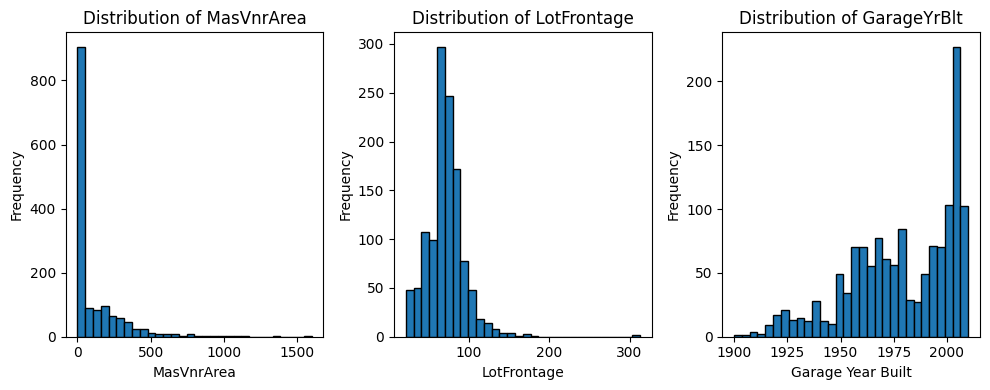

In [26]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
train_df["MasVnrArea"].plot(
    kind="hist",
    bins=30,
    edgecolor="black"
)
plt.title("Distribution of MasVnrArea")
plt.xlabel("MasVnrArea")
plt.ylabel("Frequency")

plt.subplot(1, 3, 2)
train_df["LotFrontage"].dropna().plot(
    kind="hist",
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of LotFrontage")
plt.xlabel("LotFrontage")
plt.ylabel("Frequency")

plt.subplot(1, 3, 3)
train_df["GarageYrBlt"].dropna().plot(
    kind="hist",
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of GarageYrBlt")
plt.xlabel("Garage Year Built")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [27]:
print("MasVnrArea missing values:", train_df["MasVnrArea"].isna().sum())
print("LotFrontage missing values:", train_df["LotFrontage"].isna().sum())
print("GarageYrBlt missing values:", train_df["GarageYrBlt"].isna().sum())

MasVnrArea missing values: 8
LotFrontage missing values: 259
GarageYrBlt missing values: 81


In [28]:
train_df["MasVnrArea"] = train_df["MasVnrArea"].fillna(train_df["MasVnrArea"].median())
test_df["MasVnrArea"] = test_df["MasVnrArea"].fillna(train_df["MasVnrArea"].median())
train_df["GarageYrBlt"] = train_df["GarageYrBlt"].fillna(train_df["GarageYrBlt"].median())
test_df["GarageYrBlt"] = test_df["GarageYrBlt"].fillna(train_df["GarageYrBlt"].median())
train_df["LotFrontage"] = train_df["LotFrontage"].fillna(train_df["LotFrontage"].median())
test_df["LotFrontage"] = test_df["LotFrontage"].fillna(train_df["LotFrontage"].median())

In [29]:
# Drop columns with missing values
train_df.drop(columns=['Id', 'Alley', 'SaleCondition', 'MoSold', 'YrSold', 'SaleType'], inplace=True)
test_df.drop(columns=['Alley', 'SaleCondition', 'MoSold', 'YrSold', 'SaleType'], inplace=True)

In [30]:
print(f"Train shape: {train_df.shape} | Test shape: {test_df.shape}")

Train shape: (1460, 75) | Test shape: (1459, 75)


In [31]:
ordinal_columns = [
    'BsmtQual',
    'BsmtCond',
    'BsmtExposure',
    'BsmtFinType1',
    'BsmtFinType2',
    'FireplaceQu',
    'LotShape',
    'LandSlope',
    'ExterQual',
    'ExterCond',
    'GarageQual',
    'GarageCond',
    'PoolQC',
    'HeatingQC',
    'Fence',
    'KitchenQual',
    'Functional',
    'Utilities',
    'GarageFinish',
    'PavedDrive'
]

nominal_columns = [
    'MasVnrType',
    'Electrical',
    'MiscFeature',
    'GarageType',
    'MSZoning',
    'Street',
    'LandContour',
    'LotConfig',
    'Neighborhood',
    'Condition1',
    'Condition2',
    'BldgType',
    'HouseStyle',
    'RoofStyle',
    'RoofMatl',
    'Exterior1st',
    'Exterior2nd',
    'Foundation',
    'Heating',
    'CentralAir',
]

In [32]:
# --- Ordinal encoding with EXPLICIT, domain-correct order ---
# Higher integer = better quality / more desirable. 0 = feature absent (No Basement/Garage/Pool...).
ordinal_mappings = {
    "BsmtQual":     {"NB": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "BsmtCond":     {"NB": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "BsmtExposure": {"NB": 0, "No": 1, "Mn": 2, "Av": 3, "Gd": 4},
    "BsmtFinType1": {"NB": 0, "Unf": 1, "LwQ": 2, "Rec": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6},
    "BsmtFinType2": {"NB": 0, "Unf": 1, "LwQ": 2, "Rec": 3, "BLQ": 4, "ALQ": 5, "GLQ": 6},
    "FireplaceQu":  {"NF": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "LotShape":     {"IR3": 0, "IR2": 1, "IR1": 2, "Reg": 3},
    "LandSlope":    {"Sev": 0, "Mod": 1, "Gtl": 2},
    "ExterQual":    {"Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "ExterCond":    {"Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "GarageQual":   {"NG": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "GarageCond":   {"NG": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "PoolQC":       {"NP": 0, "Fa": 1, "TA": 2, "Gd": 3, "Ex": 4},
    "HeatingQC":    {"Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "Fence":        {"NF": 0, "MnWw": 1, "GdWo": 2, "MnPrv": 3, "GdPrv": 4},
    "KitchenQual":  {"Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "Functional":   {"Sal": 0, "Sev": 1, "Maj2": 2, "Maj1": 3, "Mod": 4, "Min2": 5, "Min1": 6, "Typ": 7},
    "Utilities":    {"ELO": 0, "NoSeWa": 1, "NoSewr": 2, "AllPub": 3},
    "GarageFinish": {"NG": 0, "Unf": 1, "RFn": 2, "Fin": 3},
    "PavedDrive":   {"N": 0, "P": 1, "Y": 2},
}

for col, mapping in ordinal_mappings.items():
    train_df[col] = train_df[col].map(mapping)
    test_df[col]  = test_df[col].map(mapping)

    # Any value not covered by the map (e.g. test-only NaNs) -> train median, then cast to int
    median_val = train_df[col].median()
    train_df[col] = train_df[col].fillna(median_val).astype(int)
    test_df[col]  = test_df[col].fillna(median_val).astype(int)

# One-Hot Encode nominal columns (train only here; test is handled in prepare_submission)
train_df = pd.get_dummies(
    train_df,
    columns=nominal_columns,
    dtype=int
)

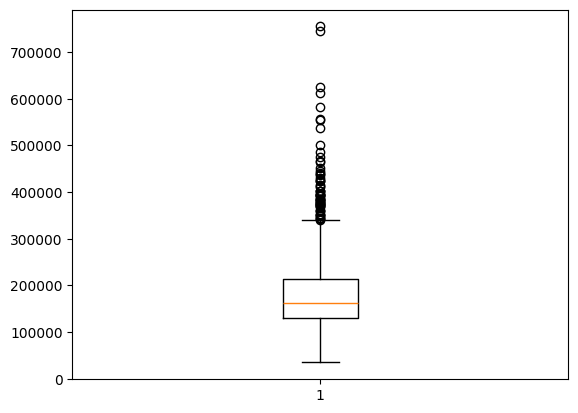

In [33]:
plt.boxplot(train_df["SalePrice"])
plt.show()

In [34]:
X = train_df.drop("SalePrice", axis=1)
y = train_df["SalePrice"]

# Split data properly into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# Identify features to scale (numerical columns with more than 2 unique values)
# Ensure target variable 'SalePrice' isn't included
scale_features = [col for col in X_train.columns if len(X_train[col].value_counts().keys()) > 2]

In [35]:
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Fit on training data
X_train_scaled[scale_features] = scaler.fit_transform(X_train[scale_features])

# Transform test data
X_test_scaled[scale_features] = scaler.transform(X_test[scale_features])

In [17]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

models = {

    # --- Linear models ---
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(random_state=42),
    "Lasso": Lasso(random_state=42),
    "ElasticNet": ElasticNet(random_state=42),

    # --- Tree ensembles (scikit-learn) ---
    "Random Forest": RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesRegressor(
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    ),

    "Hist Gradient Boosting": HistGradientBoostingRegressor(
        random_state=42
    ),

    # --- Gradient-boosting libraries ---
    "XGBoost": XGBRegressor(
        random_state=42,
        n_jobs=-1,
        tree_method="hist"
    ),

    "LightGBM": LGBMRegressor(
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    ),

    "CatBoost": CatBoostRegressor(
        random_state=42,
        verbose=0
    ),

    # --- Distance-based ---
    "KNN Regression": KNeighborsRegressor(
        n_neighbors=5
    )
}

results = []

print("🚀 Starting Model Benchmark...\n")

for name, model in models.items():

    # --- 5-fold CV on the training data ---
    cv_scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=cv,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    cv_rmse_mean = -cv_scores.mean()
    cv_rmse_std = cv_scores.std()

    # --- Fit on the full training set (timed), evaluate once on the test set ---
    fit_start = time.time()
    model.fit(X_train_scaled, y_train)
    fit_time = time.time() - fit_start

    preds = model.predict(X_test_scaled)

    # NOTE: local names are test_* so they never shadow the rmse() helper
    # defined in the stacking cell below.
    test_rmse = np.sqrt(mean_squared_error(y_test, preds))
    test_mae = mean_absolute_error(y_test, preds)
    test_r2 = r2_score(y_test, preds)

    results.append({
        "Model": name,
        "CV RMSE Mean ↓": round(cv_rmse_mean, 4),
        "CV RMSE Std": round(cv_rmse_std, 4),
        "Test RMSE ↓": round(test_rmse, 4),
        "MAE ↓": round(test_mae, 4),
        "R² Score ↑": round(test_r2, 4),
        "Fit Time (s)": round(fit_time, 3)
    })

    print(
        f"Finished {name} | "
        f"CV RMSE: {cv_rmse_mean:.4f} ± {cv_rmse_std:.4f} | "
        f"Fit: {fit_time:.3f}s"
    )

# --- Ranking table (sorting by test R² == sorting by test RMSE: same test set) ---
print("\n📊 Final Benchmark Rankings:")

df_results = (
    pd.DataFrame(results)
    .sort_values(by="R² Score ↑", ascending=False)
    .reset_index(drop=True)
)

print(df_results.to_markdown(index=False))

🚀 Starting Model Benchmark...

Finished Linear Regression | CV RMSE: 36273.4212 ± 7073.1765 | Fit: 0.101s
Finished Ridge | CV RMSE: 35146.4706 ± 6745.0102 | Fit: 0.107s


/home/almadhoun/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.818e+09, tolerance: 6.490e+08
  model = cd_fast.enet_coordinate_descent(
/home/almadhoun/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.290e+09, tolerance: 6.126e+08
  model = cd_fast.enet_coordinate_descent(
/home/almadhoun/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularis

Finished Lasso | CV RMSE: 35545.5676 ± 7017.0831 | Fit: 0.184s
Finished ElasticNet | CV RMSE: 35489.9627 ± 6398.7393 | Fit: 0.021s
Finished Random Forest | CV RMSE: 29624.6821 ± 3418.4767 | Fit: 0.514s
Finished Extra Trees | CV RMSE: 29159.9944 ± 3466.1021 | Fit: 0.451s
Finished Gradient Boosting | CV RMSE: 28361.6099 ± 5046.9946 | Fit: 0.829s
Finished Hist Gradient Boosting | CV RMSE: 28702.5933 ± 3393.3228 | Fit: 0.699s
Finished XGBoost | CV RMSE: 30912.1492 ± 5462.3696 | Fit: 1.821s
Finished LightGBM | CV RMSE: 28672.9727 ± 3056.2021 | Fit: 0.932s
Finished CatBoost | CV RMSE: 25770.4182 ± 3633.1836 | Fit: 2.607s
Finished KNN Regression | CV RMSE: 36905.9419 ± 5227.3274 | Fit: 0.004s

📊 Final Benchmark Rankings:
| Model                  |   CV RMSE Mean ↓ |   CV RMSE Std |   Test RMSE ↓ |   MAE ↓ |   R² Score ↑ |   Fit Time (s) |
|:-----------------------|-----------------:|--------------:|--------------:|--------:|-------------:|---------------:|
| CatBoost               |          

In [4]:
# Validation split (from training data only) for early stopping / tuning.
# The test set stays untouched so it remains an honest final benchmark.
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_scaled,
    y_train,
    test_size=0.1,
    random_state=42
)

NameError: name 'X_train_scaled' is not defined

In [19]:
SEED = 42

def build_voting_model(p):

    xgb_model = XGBRegressor(
        n_estimators=p["xgb_n_estimators"],
        learning_rate=p["xgb_learning_rate"],
        max_depth=p["xgb_max_depth"],
        min_child_weight=p["xgb_min_child_weight"],
        gamma=p.get("xgb_gamma", 0.0),
        subsample=p["xgb_subsample"],
        colsample_bytree=p["xgb_colsample_bytree"],
        colsample_bylevel=p.get("xgb_colsample_bylevel", 1.0),
        colsample_bynode=p.get("xgb_colsample_bynode", 1.0),
        reg_alpha=p["xgb_reg_alpha"],
        reg_lambda=p["xgb_reg_lambda"],
        max_delta_step=p.get("xgb_max_delta_step", 0),
        max_bin=p.get("xgb_max_bin", 256),
        grow_policy=p.get("xgb_grow_policy", "depthwise"),
        objective="reg:squarederror",
        tree_method="hist",
        n_jobs=-1,
        random_state=SEED
    )

    bagging_gb_model = BaggingRegressor(
        estimator=GradientBoostingRegressor(
            n_estimators=p["gb_n_estimators"],
            learning_rate=p["gb_learning_rate"],
            loss=p.get("gb_loss", "squared_error"),
            max_depth=p["gb_max_depth"],
            min_samples_split=p.get("gb_min_samples_split", 2),
            min_samples_leaf=p["gb_min_samples_leaf"],
            max_features=p.get("gb_max_features", None),
            subsample=p["gb_subsample"],
            validation_fraction=p.get("gb_validation_fraction", 0.1),
            n_iter_no_change=p.get("gb_n_iter_no_change", None),
            tol=p.get("gb_tol", 1e-4),
            random_state=SEED
        ),
        n_estimators=p["bag_n_estimators"],
        max_samples=p["bag_max_samples"],
        max_features=p["bag_max_features"],
        bootstrap=p.get("bag_bootstrap", True),
        bootstrap_features=p.get("bag_bootstrap_features", False),
        random_state=SEED,
        n_jobs=-1
    )

    return VotingRegressor(
        estimators=[
            ("xgb", xgb_model),
            ("bagging_gb", bagging_gb_model)
        ],
        weights=[p["w_xgb"], 1 - p["w_xgb"]],
        n_jobs=1
    )

In [20]:
# CatBoost Optuna study: TPE sampler + median pruning, resumable sqlite storage.
def objective(trial: optuna.Trial) -> float:
    params = {
        # Fixed
        "iterations": 1000,
        "loss_function": "RMSE",
        "eval_metric": "RMSE",
        "random_seed": 42,
        "verbose": 0,

        # Boosting
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "depth": trial.suggest_int("depth", 4, 10),

        # Regularization
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 30.0, log=True),
        "random_strength": trial.suggest_float("random_strength", 1e-3, 20.0, log=True),

        # Column sampling & binning
        "rsm": trial.suggest_float("rsm", 0.5, 1.0),
        "border_count": trial.suggest_int("border_count", 32, 255),

        # Leaf estimation
        "leaf_estimation_iterations": trial.suggest_int("leaf_estimation_iterations", 1, 10),
        "leaf_estimation_method": trial.suggest_categorical(
            "leaf_estimation_method", ["Newton", "Gradient"]
        ),
    }

    # --- Conditional: bootstrap type determines which sampling param is valid ---
    bootstrap_type = trial.suggest_categorical(
        "bootstrap_type", ["Bayesian", "Bernoulli", "MVS"]
    )
    params["bootstrap_type"] = bootstrap_type
    if bootstrap_type == "Bayesian":
        params["bagging_temperature"] = trial.suggest_float(
            "bagging_temperature", 0.0, 10.0
        )
    else:  # Bernoulli / MVS use subsample
        params["subsample"] = trial.suggest_float("subsample", 0.5, 1.0)

    # --- Conditional: grow policy determines valid tree-structure params ---
    grow_policy = trial.suggest_categorical(
        "grow_policy", ["SymmetricTree", "Depthwise", "Lossguide"]
    )
    params["grow_policy"] = grow_policy
    if grow_policy in ("Depthwise", "Lossguide"):
        params["min_data_in_leaf"] = trial.suggest_int("min_data_in_leaf", 1, 100)
    if grow_policy == "Lossguide":
        params["max_leaves"] = trial.suggest_int("max_leaves", 16, 64)

    model = CatBoostRegressor(**params)
    pruning_callback = CatBoostPruningCallback(trial, "RMSE")

    model.fit(
        X_tr,
        y_tr,
        eval_set=(X_val, y_val),
        early_stopping_rounds=100,
        callbacks=[pruning_callback],
        verbose=False,
    )
    pruning_callback.check_pruned()

    # Store the early-stopped iteration count for final retraining
    trial.set_user_attr("best_iteration", model.get_best_iteration())

    # Best (not final) validation score, matching early stopping
    return model.get_best_score()["validation"]["RMSE"]

optuna.logging.set_verbosity(optuna.logging.WARNING)

study = optuna.create_study(
    study_name="catboost_rmse",
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42, multivariate=True),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=200),
    storage="sqlite:///catboost_optuna.db",
    load_if_exists=True,  # resume if interrupted
)

study.optimize(
    objective,
    n_trials=500,
    timeout=None,          # or e.g. 6 * 3600 for a 6h budget
    show_progress_bar=True,
)

print(f"Best validation RMSE: {study.best_value:.4f}")
print("Best parameters:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

# Tuned params + the early-stopped tree count (inside a stack there is no
# eval_set, so iterations must be a fixed value). Persisted to ../models/best_params.txt:
# every downstream cell reads that file, so tuning never needs to be rerun.
best_it = study.best_trial.user_attrs.get("best_iteration")
catboost_candidate = dict(study.best_params)
catboost_candidate["iterations"] = (best_it + 1) if best_it is not None else 1000

try:
    with open("../models/best_params.txt") as f:
        saved_params = json.load(f)
except FileNotFoundError:
    saved_params = {}

saved_params["catboost"] = catboost_candidate
with open("../models/best_params.txt", "w") as f:
    json.dump(saved_params, f, indent=2)

print("\nSaved CatBoost best params to ../models/best_params.txt:")
print(json.dumps(catboost_candidate, indent=2))

/tmp/ipykernel_5399/3141053736.py:76: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler=optuna.samplers.TPESampler(seed=42, multivariate=True),


  0%|          | 0/500 [00:00<?, ?it/s]

/tmp/ipykernel_5399/3141053736.py:53: ExperimentalWarning: CatBoostPruningCallback is experimental (supported from v3.0.0). The interface can change in the future.
  pruning_callback = CatBoostPruningCallback(trial, "RMSE")


Best validation RMSE: 18136.6333
Best parameters:
  learning_rate: 0.062464179851267024
  depth: 5
  l2_leaf_reg: 2.2637606510801906
  random_strength: 1.6323415045159653
  rsm: 0.7415415569975424
  border_count: 149
  leaf_estimation_iterations: 3
  leaf_estimation_method: Gradient
  bootstrap_type: Bayesian
  bagging_temperature: 0.09637500273284247
  grow_policy: Depthwise
  min_data_in_leaf: 1

Saved CatBoost best params to ../models/best_params.txt:
{
  "learning_rate": 0.062464179851267024,
  "depth": 5,
  "l2_leaf_reg": 2.2637606510801906,
  "random_strength": 1.6323415045159653,
  "rsm": 0.7415415569975424,
  "border_count": 149,
  "leaf_estimation_iterations": 3,
  "leaf_estimation_method": "Gradient",
  "bootstrap_type": "Bayesian",
  "bagging_temperature": 0.09637500273284247,
  "grow_policy": "Depthwise",
  "min_data_in_leaf": 1,
  "iterations": 342
}


In [21]:
GB_FIXED = {
    "gb_validation_fraction": 0.15,
    "gb_n_iter_no_change": 15,
    "gb_tol": 1e-4,
}

def optimal_blend_weight(y_true, pred_a, pred_b):
    """Closed-form RMSE-optimal weight w for  w*pred_a + (1-w)*pred_b,  clipped to [0, 1]."""
    diff = pred_a - pred_b
    denom = np.dot(diff, diff)
    if denom < 1e-12:
        return 0.5
    w = np.dot(y_true - pred_b, diff) / denom
    return float(np.clip(w, 0.0, 1.0))


def voting_objective(trial: optuna.Trial) -> float:
    p = {
        # ---------- XGBoost ----------
        "xgb_n_estimators": trial.suggest_int("xgb_n_estimators", 300, 2500),
        "xgb_learning_rate": trial.suggest_float("xgb_learning_rate", 0.005, 0.1, log=True),
        "xgb_max_depth": trial.suggest_int("xgb_max_depth", 3, 10),
        "xgb_min_child_weight": trial.suggest_int("xgb_min_child_weight", 1, 15),
        "xgb_gamma": trial.suggest_float("xgb_gamma", 1e-3, 10.0, log=True),
        "xgb_subsample": trial.suggest_float("xgb_subsample", 0.5, 1.0),
        # one column-sampling knob is enough; bylevel/bynode add dims for little gain
        "xgb_colsample_bytree": trial.suggest_float("xgb_colsample_bytree", 0.5, 1.0),
        "xgb_colsample_bylevel": 1.0,
        "xgb_colsample_bynode": 1.0,
        "xgb_reg_alpha": trial.suggest_float("xgb_reg_alpha", 1e-3, 20.0, log=True),
        "xgb_reg_lambda": trial.suggest_float("xgb_reg_lambda", 0.1, 20.0, log=True),
        "xgb_max_delta_step": 0,  # for imbalanced classification; irrelevant here
        "xgb_max_bin": trial.suggest_int("xgb_max_bin", 128, 512),
        "xgb_grow_policy": trial.suggest_categorical(
            "xgb_grow_policy", ["depthwise", "lossguide"]
        ),

        # ---------- GradientBoostingRegressor ----------
        "gb_n_estimators": trial.suggest_int("gb_n_estimators", 100, 800),
        "gb_learning_rate": trial.suggest_float("gb_learning_rate", 0.005, 0.2, log=True),
        "gb_loss": trial.suggest_categorical(
            "gb_loss", ["squared_error", "absolute_error", "huber"]
        ),
        "gb_max_depth": trial.suggest_int("gb_max_depth", 2, 6),
        "gb_min_samples_split": trial.suggest_int("gb_min_samples_split", 2, 20),
        "gb_min_samples_leaf": trial.suggest_int("gb_min_samples_leaf", 1, 20),
        "gb_max_features": trial.suggest_categorical(
            "gb_max_features", [None, "sqrt", "log2"]
        ),
        "gb_subsample": trial.suggest_float("gb_subsample", 0.5, 0.9),
        **GB_FIXED,

        # ---------- BaggingRegressor ----------
        "bag_n_estimators": trial.suggest_int("bag_n_estimators", 5, 20),
        "bag_max_samples": trial.suggest_float("bag_max_samples", 0.5, 1.0),
        "bag_max_features": trial.suggest_float("bag_max_features", 0.5, 1.0),
        "bag_bootstrap": trial.suggest_categorical("bag_bootstrap", [True, False]),
        "bag_bootstrap_features": trial.suggest_categorical(
            "bag_bootstrap_features", [True, False]
        ),

        # placeholder — solved in closed form below, not tuned
        "w_xgb": 0.5,
    }

    # Build the voting model once to fit both base models with identical settings
    model = build_voting_model(p)
    model.fit(X_tr, y_tr)

    # Predict with each fitted base estimator separately, then solve the
    # RMSE-optimal blend weight analytically instead of tuning it.
    pred_xgb, pred_bag = (est.predict(X_val) for est in model.estimators_)
    w = optimal_blend_weight(y_val, pred_xgb, pred_bag)

    blended = w * pred_xgb + (1.0 - w) * pred_bag
    rmse = np.sqrt(mean_squared_error(y_val, blended))

    # Persist the solved weight so the final rebuild uses it
    trial.set_user_attr("w_xgb", w)
    trial.set_user_attr("rmse_xgb", float(np.sqrt(mean_squared_error(y_val, pred_xgb))))
    trial.set_user_attr("rmse_bag", float(np.sqrt(mean_squared_error(y_val, pred_bag))))

    return rmse

# --- Study: seeded sampler, persistent storage; no pruner (no intermediate scores) ---
optuna.logging.set_verbosity(optuna.logging.WARNING)

voting_study = optuna.create_study(
    study_name="voting_xgb_bag_gb_v2",
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=SEED, multivariate=True),
    pruner=optuna.pruners.NopPruner(),  # VotingRegressor exposes no intermediate signal
    storage="sqlite:///voting_optuna.db",
    load_if_exists=True,
)
 
voting_study.optimize(
    voting_objective,
    n_trials=200,
    timeout=None,
    show_progress_bar=True,
)
 
best_w = voting_study.best_trial.user_attrs["w_xgb"]
print(f"Best validation RMSE: {voting_study.best_value:.4f}")
print(f"Solved blend weight w_xgb: {best_w:.3f}")
print(f"  (XGB alone: {voting_study.best_trial.user_attrs['rmse_xgb']:.4f}, "
      f"Bag(GB) alone: {voting_study.best_trial.user_attrs['rmse_bag']:.4f})")
print("Best parameters:")
for k, v in voting_study.best_params.items():
    print(f"  {k}: {v}")

# Persist: tuned params + fixed GB settings + the solved blend weight.
# (w_xgb is NOT in best_params -- it is solved in closed form, not searched.)
voting_candidate = {**voting_study.best_params, **GB_FIXED, "w_xgb": best_w}

try:
    with open("../models/best_params.txt") as f:
        saved_params = json.load(f)
except FileNotFoundError:
    saved_params = {}

saved_params["voting"] = voting_candidate
with open("../models/best_params.txt", "w") as f:
    json.dump(saved_params, f, indent=2)

print("\nSaved voting best params to ../models/best_params.txt")

/tmp/ipykernel_5399/729943802.py:91: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler=optuna.samplers.TPESampler(seed=SEED, multivariate=True),


  0%|          | 0/200 [00:00<?, ?it/s]

Best validation RMSE: 18222.8536
Solved blend weight w_xgb: 0.000
  (XGB alone: 21152.4539, Bag(GB) alone: 18222.8536)
Best parameters:
  xgb_n_estimators: 1474
  xgb_learning_rate: 0.025099813031353408
  xgb_max_depth: 6
  xgb_min_child_weight: 12
  xgb_gamma: 0.16405974657973155
  xgb_subsample: 0.7139424512603495
  xgb_colsample_bytree: 0.6797564888883734
  xgb_reg_alpha: 1.9491619354045384
  xgb_reg_lambda: 4.138878435813889
  xgb_max_bin: 309
  xgb_grow_policy: lossguide
  gb_n_estimators: 776
  gb_learning_rate: 0.171865169604279
  gb_loss: huber
  gb_max_depth: 2
  gb_min_samples_split: 5
  gb_min_samples_leaf: 8
  gb_max_features: None
  gb_subsample: 0.8348430267996356
  bag_n_estimators: 14
  bag_max_samples: 0.903313324307487
  bag_max_features: 0.6449638350616795
  bag_bootstrap: False
  bag_bootstrap_features: False

Saved voting best params to ../models/best_params.txt


In [22]:
# Rebuild the best voting model from ../models/best_params.txt, retrain on the FULL
# training data (X_tr + X_val = X_train_scaled) and evaluate once on the
# held-out test set. The file is written by the Optuna study cells above,
# so this cell also works in a fresh session without re-tuning.

try:
    with open("../models/best_params.txt") as f:
        final_voting_params = json.load(f)["voting"]
except FileNotFoundError:
    raise FileNotFoundError(
        "../models/best_params.txt not found -- run the two Optuna study cells once to create it."
    ) from None

print(f"Loaded voting params from ../models/best_params.txt (w_xgb = {final_voting_params['w_xgb']:.3f})")

best_voting = build_voting_model(final_voting_params)
best_voting.fit(X_train_scaled, y_train)

test_pred_voting = best_voting.predict(X_test_scaled)
test_rmse_voting = np.sqrt(mean_squared_error(y_test, test_pred_voting))

print(f"Test RMSE: {test_rmse_voting:.4f}")
print(f"Test R²:   {r2_score(y_test, test_pred_voting):.4f}")

print("\nVoting params in use:")
print(json.dumps(final_voting_params, indent=2))

Loaded voting params from ../models/best_params.txt (w_xgb = 0.000)
Test RMSE: 30831.4119
Test R²:   0.8960

Voting params in use:
{
  "xgb_n_estimators": 1474,
  "xgb_learning_rate": 0.025099813031353408,
  "xgb_max_depth": 6,
  "xgb_min_child_weight": 12,
  "xgb_gamma": 0.16405974657973155,
  "xgb_subsample": 0.7139424512603495,
  "xgb_colsample_bytree": 0.6797564888883734,
  "xgb_reg_alpha": 1.9491619354045384,
  "xgb_reg_lambda": 4.138878435813889,
  "xgb_max_bin": 309,
  "xgb_grow_policy": "lossguide",
  "gb_n_estimators": 776,
  "gb_learning_rate": 0.171865169604279,
  "gb_loss": "huber",
  "gb_max_depth": 2,
  "gb_min_samples_split": 5,
  "gb_min_samples_leaf": 8,
  "gb_max_features": null,
  "gb_subsample": 0.8348430267996356,
  "bag_n_estimators": 14,
  "bag_max_samples": 0.903313324307487,
  "bag_max_features": 0.6449638350616795,
  "bag_bootstrap": false,
  "bag_bootstrap_features": false,
  "gb_validation_fraction": 0.15,
  "gb_n_iter_no_change": 15,
  "gb_tol": 0.0001,
  "

In [23]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


# --- Load the tuned hyperparameters from ../models/best_params.txt ---
# The file is written by the two Optuna study cells; keeping the params in a
# file (not hardcoded) means re-tuning automatically feeds the final model.
try:
    with open("../models/best_params.txt") as f:
        _saved = json.load(f)
except FileNotFoundError:
    raise FileNotFoundError(
        "../models/best_params.txt not found -- run the two Optuna study cells once to create it."
    ) from None

CATBOOST_PARAMS = _saved["catboost"]
VOTING_PARAMS = _saved["voting"]
print(f"Loaded best params from ../models/best_params.txt (w_xgb = {VOTING_PARAMS['w_xgb']:.3f})")
 

stack_estimators = [
    (
        "catboost",
        CatBoostRegressor(
            **CATBOOST_PARAMS,
            loss_function="RMSE",
            verbose=0,
            random_seed=SEED
        )
    ),
    (
        "voting_xgb_bgb",
        build_voting_model(VOTING_PARAMS)
    )
]

stack_model = StackingRegressor(
    estimators=stack_estimators,
    final_estimator=RidgeCV(alphas=np.logspace(-4, 3, 30)),
    cv=KFold(n_splits=5, shuffle=True, random_state=SEED),
    n_jobs=1
)

stack_model.fit(X_train_scaled, y_train)


# --- Held-out test performance: stack vs. each base model ---
test_pred_stack = stack_model.predict(X_test_scaled)

results = {"stack": rmse(y_test, test_pred_stack)}
for name, est in zip([n for n, _ in stack_estimators], stack_model.estimators_):
    results[name] = rmse(y_test, est.predict(X_test_scaled))

print("Test RMSE comparison:")
for name, score in sorted(results.items(), key=lambda kv: kv[1]):
    marker = "  <-- best" if score == min(results.values()) else ""
    print(f"  {name:16s} {score:.4f}{marker}")

print(f"\nStack Test R²: {r2_score(y_test, test_pred_stack):.4f}")

# --- Meta-model inspection ---
fe = stack_model.final_estimator_
print(f"\nRidge alpha selected: {fe.alpha_:.4g}")
print(f"Intercept: {fe.intercept_:.4f}")
print("Stack weights (Ridge coefficients):")
for (name, _), coef in zip(stack_estimators, fe.coef_):
    print(f"  {name}: {coef:.4f}")

Loaded best params from ../models/best_params.txt (w_xgb = 0.000)
Test RMSE comparison:
  stack            28252.6318  <-- best
  catboost         28541.4652
  voting_xgb_bgb   30831.4119

Stack Test R²: 0.9126

Ridge alpha selected: 1000
Intercept: -5374.7784
Stack weights (Ridge coefficients):
  catboost: 0.7036
  voting_xgb_bgb: 0.3271


In [ ]:
X_full_scaled = X.copy()
X_full_scaled[scale_features] = scaler.transform(X[scale_features])

final_stack_model = StackingRegressor(
    estimators=[
        (
            "catboost",
            CatBoostRegressor(
                **CATBOOST_PARAMS,
                loss_function="RMSE",
                verbose=0,
                random_seed=SEED
            )
        ),
        (
            "voting_xgb_bgb",
            build_voting_model(VOTING_PARAMS)
        )
    ],
    final_estimator=RidgeCV(alphas=np.logspace(-4, 3, 30)),
    cv=KFold(n_splits=5, shuffle=True, random_state=SEED),
    n_jobs=1
)

final_stack_model.fit(X_full_scaled, y)

print(f"Final stack trained on all {len(X_full_scaled)} labeled rows")

print("\nStack weights (Ridge coefficients):")
for name, coef in zip(
    final_stack_model.named_estimators_,
    final_stack_model.final_estimator_.coef_
):
    print(f"  {name}: {coef:.4f}")

NameError: name 'build_voting_model' is not defined

In [32]:
# --- Persist the final stack model plus everything needed to predict from raw data ---
# The model alone is not enough at inference time: the scaler, the training column
# layout, the ordinal/nominal encoding constants, and the NA-fill values must travel
# with it, so bundle them into one artifact.
import os
import sys
import joblib
import sklearn
import xgboost
import catboost

# Raw-data categorical NA fills (mirrors the cleaning cells at the top of the notebook)
CAT_NA_FILLS = {
    "MasVnrType": "None", "MiscFeature": "None", "Electrical": "SBrkr",
    "BsmtQual": "NB", "BsmtCond": "NB", "BsmtExposure": "NB",
    "BsmtFinType1": "NB", "BsmtFinType2": "NB",
    "FireplaceQu": "NF", "Fence": "NF",
    "GarageType": "NG", "GarageFinish": "NG", "GarageQual": "NG", "GarageCond": "NG",
    "PoolQC": "NP",
}

artifact = {
    "model": final_stack_model,
    "scaler": scaler,
    "scale_features": scale_features,
    "feature_columns": X.columns.tolist(),
    "train_medians": X.median(numeric_only=True),  # fills any numeric NaNs at inference
    "nominal_columns": nominal_columns,
    "ordinal_mappings": ordinal_mappings,
    "cat_na_fills": CAT_NA_FILLS,
    "drop_columns": ["Alley", "SaleCondition", "MoSold", "YrSold", "SaleType"],
    # Pickles are tied to library versions -- record them so a load-time
    # mismatch can be diagnosed instead of guessed at.
    "versions": {
        "python": sys.version.split()[0],
        "scikit-learn": sklearn.__version__,
        "xgboost": xgboost.__version__,
        "catboost": catboost.__version__,
        "pandas": pd.__version__,
        "numpy": np.__version__,
    },
}

joblib.dump(artifact, "../models/final_stack_model.joblib", compress=3)
print(f"Saved ../models/final_stack_model.joblib "
      f"({os.path.getsize('../models/final_stack_model.joblib') / 1e6:.1f} MB)")

NameError: name 'final_stack_model' is not defined

In [33]:
def prepare_submission(test_raw_df):
    
    ids = test_raw_df["Id"]
    df = test_raw_df.copy()

    # NOTE: ordinal columns are ALREADY encoded (mapped for both train & test in the
    # encoding step), so we do NOT re-encode them here -- we only one-hot the nominals.
    df = pd.get_dummies(df, columns=nominal_columns, dtype=int)

    # Fill any remaining numeric NaNs using train medians (no leakage)
    # (test.csv has NaNs in numeric cols train doesn't: GarageCars, GarageArea, etc.)
    df = df.fillna(X.median(numeric_only=True))

    # Align to the exact training feature set (adds missing dummies as 0, drops extras)
    df = df.reindex(columns=X.columns, fill_value=0)

    # Scale the same continuous columns, using the same scaler applied to the
    # final model's training data
    df_scaled = df.copy()
    df_scaled[scale_features] = scaler.transform(df[scale_features])

    # Predict with the final stacking ensemble (retrained on ALL 1460 labeled rows)
    predictions = final_stack_model.predict(df_scaled)
    return predictions, ids

# Generate final predictions
final_predictions, ids = prepare_submission(test_df)

NameError: name 'final_stack_model' is not defined

In [34]:
# Create submission DataFrame
submission_df = pd.DataFrame({
    'Id': ids,
    'SalePrice': final_predictions
})
print("--- Submission Preview ---")
print(submission_df.head())

NameError: name 'ids' is not defined

In [28]:
submission_df.to_csv('../outputs/submission.csv', index=False)

In [36]:
# --- Reload the saved artifact and verify it reproduces the submission predictions ---
# This function only needs the artifact + pandas/numpy, so it can be copied into a
# fresh script or service as-is: it takes a raw test.csv-style DataFrame end to end.
import joblib

art = joblib.load("../models/final_stack_model.joblib")
print("Artifact saved with:", art["versions"])


def predict_from_raw(raw_df, art):
    df = raw_df.drop(columns=art["drop_columns"]).fillna(art["cat_na_fills"])

    for col, mapping in art["ordinal_mappings"].items():
        df[col] = df[col].map(mapping)

    df = pd.get_dummies(df, columns=art["nominal_columns"], dtype=int)
    df = df.fillna(art["train_medians"])
    df = df.reindex(columns=art["feature_columns"], fill_value=0)
    df[art["scale_features"]] = art["scaler"].transform(df[art["scale_features"]])
    return art["model"].predict(df)


# Re-read test.csv untouched (the in-memory test_df was already preprocessed above)
raw_test = pd.read_csv("../data/test.csv")
reloaded_preds = predict_from_raw(raw_test, art)


Artifact saved with: {'python': '3.13.9', 'scikit-learn': '1.8.0', 'xgboost': '3.3.0', 'catboost': '1.2.10', 'pandas': '3.0.1', 'numpy': '2.4.0'}


In [ ]:
# --- Bonus experiment: how well does the stack do with ONLY the 10 most important features? ---
# Feature importance is read from the LOADED artifact (../models/final_stack_model.joblib),
# i.e. the saved production model trained on all labeled rows:
#   - CatBoost branch: its built-in feature importances.
#   - Voting branch: XGB and Bagging(GB) importances mixed with the blend weights
#     stored inside the fitted voting model [w_xgb, 1 - w_xgb]. Each bagged GB was
#     trained on a random subset of columns, so its importances are mapped back to
#     the full feature list first.
# Every source is normalized to sum to 1 before averaging, so the scales are comparable.
import joblib

loaded_art = joblib.load("../models/final_stack_model.joblib")
loaded_model = loaded_art["model"]
feat_names = pd.Index(loaded_art["feature_columns"])

def normalized_importance(values):
    s = pd.Series(values, index=feat_names)
    return s / s.sum()

imp_catboost = normalized_importance(
    loaded_model.named_estimators_["catboost"].feature_importances_
)

voting_fitted = loaded_model.named_estimators_["voting_xgb_bgb"]
imp_xgb = normalized_importance(
    voting_fitted.named_estimators_["xgb"].feature_importances_
)

bagging_fitted = voting_fitted.named_estimators_["bagging_gb"]
bag_totals = np.zeros(len(feat_names))
for gb_est, gb_cols in zip(bagging_fitted.estimators_, bagging_fitted.estimators_features_):
    bag_totals[gb_cols] += gb_est.feature_importances_
imp_bagging = normalized_importance(bag_totals)

w_xgb_loaded = voting_fitted.weights[0]
stack_importance = (imp_catboost + (w_xgb_loaded * imp_xgb + (1 - w_xgb_loaded) * imp_bagging)) / 2

top10_features = stack_importance.nlargest(10).index.tolist()

print("Top 10 features by loaded-model importance:")
for rank, feat in enumerate(top10_features, 1):
    print(f"  {rank:2d}. {feat:<22s} {stack_importance[feat]:6.1%}")

# --- Retrain the SAME stack architecture (same tuned params) on only these 10 columns ---
# The top-10 model is trained on the train split and scored on the held-out test set.
# The loaded model itself saw ALL rows during training, so the fair full-feature
# baseline on this test set is the train-split stack from the stacking cell above.
stack_top10 = StackingRegressor(
    estimators=[
        (
            "catboost",
            CatBoostRegressor(
                **CATBOOST_PARAMS,
                loss_function="RMSE",
                verbose=0,
                random_seed=SEED
            )
        ),
        (
            "voting_xgb_bgb",
            build_voting_model(VOTING_PARAMS)
        )
    ],
    final_estimator=RidgeCV(alphas=np.logspace(-4, 3, 30)),
    cv=KFold(n_splits=5, shuffle=True, random_state=SEED),
    n_jobs=1
)

stack_top10.fit(X_train_scaled[top10_features], y_train)
test_pred_top10 = stack_top10.predict(X_test_scaled[top10_features])

print(f"\nFull stack   ({len(feat_names)} features) | "
      f"Test RMSE: {rmse(y_test, test_pred_stack):.4f} | "
      f"Test R²: {r2_score(y_test, test_pred_stack):.4f}")
print(f"Top-10 stack (10 features)  | "
      f"Test RMSE: {rmse(y_test, test_pred_top10):.4f} | "
      f"Test R²: {r2_score(y_test, test_pred_top10):.4f}")

Top 10 features by loaded-model importance:
   1. OverallQual             25.6%
   2. GrLivArea               10.7%
   3. ExterQual                8.9%
   4. GarageCars               7.3%
   5. KitchenQual              5.1%
   6. TotalBsmtSF              4.8%
   7. YearBuilt                2.9%
   8. 1stFlrSF                 2.9%
   9. GarageFinish             2.8%
  10. FullBath                 2.6%


TypeError: catboost.core.CatBoostRegressor() got multiple values for keyword argument 'loss_function'